In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [4]:
X_scaled = StandardScaler().fit_transform(X)

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

df["Cluster"] = dbscan.fit_predict(X_scaled)

print(df[["Annual Income (k$)", "Spending Score (1-100)", "Cluster"]].head())

   Annual Income (k$)  Spending Score (1-100)  Cluster
0                  15                      39        0
1                  15                      81        0
2                  16                       6        0
3                  16                      77        0
4                  17                      40        0


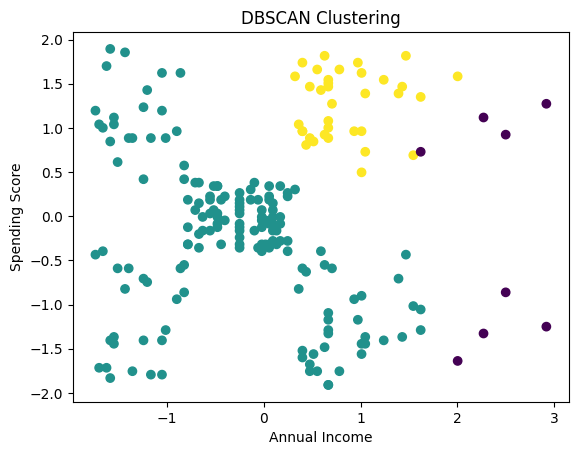

In [6]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()

In [7]:
print("Cluster values:")
print(df["Cluster"].value_counts())

Cluster values:
Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64
